# Cache vs Prefetch Benchmark Plots

This notebook builds a benchmark-level speedup plot using:
- `results/cache_new_benchmarks.csv`
- `results/prefetch_new_benchmarks.csv`

For the prefetch data, the default behavior is to choose the **best IPC across all `min_layer_distance` values** for each `(benchmark, intermediate_capacity, eviction_policy)` pair, so each capacity gets exactly one prefetch `lru` bar and one prefetch `rri` bar.

In [30]:
import csv
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt

ROOT = Path.cwd()
RESULTS_DIR = ROOT if (ROOT / 'cache_new_benchmarks.csv').exists() else ROOT / 'results'
CACHE_CSV = RESULTS_DIR / 'cache_new_benchmarks.csv'
PREFETCH_CSV = RESULTS_DIR / 'prefetch_new_benchmarks.csv'

def load_rows(path):
    with open(path, newline='') as f:
        return list(csv.DictReader(f))

def to_float(value):
    if value in ('', None):
        return None
    return float(value)

def to_int(value):
    if value in ('', None):
        return None
    return int(float(value))

CACHE_ROWS = load_rows(CACHE_CSV)
PREFETCH_ROWS = load_rows(PREFETCH_CSV)
AVAILABLE_BENCHMARKS = sorted(set(row['benchmark'] for row in CACHE_ROWS) | set(row['benchmark'] for row in PREFETCH_ROWS))
AVAILABLE_BENCHMARKS


['bose_hubbard_q',
 'bose_hubbard_t',
 'chromium_q',
 'chromium_t',
 'ethylene_oxide_q',
 'ethylene_oxide_t',
 'grover_3sat',
 'hc3h2cn_q',
 'hc3h2cn_t',
 'manganese_nitride_q',
 'manganese_nitride_t',
 'shor_rsa24']

In [34]:
def _pick_prefetch_rows(rows, selected_mld=None):
    grouped = defaultdict(list)
    for row in rows:
        if row['eviction_policy'] not in {'lru', 'rri'}:
            continue
        cap = to_int(row['intermediate_capacity'])
        mld = to_int(row['min_layer_distance'])
        if selected_mld is not None and mld != selected_mld:
            continue
        grouped[(cap, row['eviction_policy'])].append(row)

    chosen = {}
    for key, group in grouped.items():
        chosen[key] = max(group, key=lambda row: to_float(row['ipc']) or float('-inf'))
    return chosen


def _benchmark_plot_data(label, selected_mld=None):
    cache_rows = [row for row in CACHE_ROWS if row['benchmark'] == label]
    prefetch_rows = [row for row in PREFETCH_ROWS if row['benchmark'] == label]

    if not cache_rows and not prefetch_rows:
        raise ValueError(f'No rows found for benchmark: {label}')

    cache_baseline = next((row for row in cache_rows if row['eviction_policy'] == 'eif_baseline'), None)
    prefetch_baseline = next((row for row in prefetch_rows if row['eviction_policy'] == 'eif'), None)
    baseline_row = cache_baseline or prefetch_baseline
    baseline_ipc = to_float(baseline_row['ipc']) if baseline_row else None
    if baseline_ipc in (None, 0.0):
        raise ValueError(f'Could not determine a non-zero baseline IPC for {label}')

    ideal_row = next((row for row in prefetch_rows if row['eviction_policy'] == 'ideal_memory'), None)
    ideal_ipc = to_float(ideal_row['ipc']) if ideal_row else None
    ideal_speedup = (ideal_ipc / baseline_ipc) if ideal_ipc is not None else None

    cache_speedups = {}
    for row in cache_rows:
        policy = row['eviction_policy']
        if policy not in {'lru', 'rri'}:
            continue
        cap = to_int(row['intermediate_capacity'])
        ipc = to_float(row['ipc'])
        cache_speedups[(cap, policy)] = (ipc / baseline_ipc) if ipc is not None else None

    prefetch_choice = _pick_prefetch_rows(prefetch_rows, selected_mld=selected_mld)
    prefetch_speedups = {}
    prefetch_mlds = {}
    for key, row in prefetch_choice.items():
        ipc = to_float(row['ipc'])
        prefetch_speedups[key] = (ipc / baseline_ipc) if ipc is not None else None
        prefetch_mlds[key] = to_int(row['min_layer_distance'])

    capacities = sorted({cap for cap, _ in cache_speedups.keys()} | {cap for cap, _ in prefetch_speedups.keys()})
    if not capacities:
        raise ValueError(f'No capacity sweep rows available for {label}')

    return {
        'label': label,
        'baseline_ipc': baseline_ipc,
        'ideal_speedup': ideal_speedup,
        'cache_speedups': cache_speedups,
        'prefetch_speedups': prefetch_speedups,
        'prefetch_mlds': prefetch_mlds,
        'capacities': capacities,
    }


def _draw_benchmark_speedup_on_axis(ax, plot_data, selected_mld=None, annotate_prefetch_mld=True, show_ylabel=True):
    capacities = plot_data['capacities']
    cache_speedups = plot_data['cache_speedups']
    prefetch_speedups = plot_data['prefetch_speedups']
    prefetch_mlds = plot_data['prefetch_mlds']
    ideal_speedup = plot_data['ideal_speedup']
    label = plot_data['label']

    x = list(range(len(capacities)))
    width = 0.18
    offsets = {
        ('cache', 'lru'): -1.5 * width,
        ('cache', 'rri'): -0.5 * width,
        ('prefetch', 'lru'): 0.5 * width,
        ('prefetch', 'rri'): 1.5 * width,
    }
    colors = {
        ('cache', 'lru'): '#4C78A8',
        ('cache', 'rri'): '#72B7B2',
        ('prefetch', 'lru'): '#F58518',
        ('prefetch', 'rri'): '#E45756',
    }
    labels = {
        ('cache', 'lru'): 'Cache LRU',
        ('cache', 'rri'): 'Cache RRI',
        ('prefetch', 'lru'): 'Prefetch LRU',
        ('prefetch', 'rri'): 'Prefetch RRI',
    }

    legend_handles = {}

    def draw_series(kind, policy):
        heights = []
        positions = []
        cap_keys = []
        for idx, cap in enumerate(capacities):
            key = (cap, policy)
            value = cache_speedups.get(key) if kind == 'cache' else prefetch_speedups.get(key)
            if value is None:
                continue
            positions.append(x[idx] + offsets[(kind, policy)])
            heights.append(value)
            cap_keys.append(cap)

        bars = ax.bar(positions, heights, width=width, color=colors[(kind, policy)], label=labels[(kind, policy)])
        if len(bars) > 0:
            legend_handles[(kind, policy)] = bars

        if kind == 'prefetch' and annotate_prefetch_mld:
            for bar, cap in zip(bars, cap_keys):
                mld = prefetch_mlds.get((cap, policy))
                if mld is not None:
                    ax.text(
                        bar.get_x() + bar.get_width() / 2,
                        bar.get_height(),
                        f'mld={mld}',
                        ha='center',
                        va='bottom',
                        fontsize=7,
                        rotation=90,
                    )

    draw_series('cache', 'lru')
    draw_series('cache', 'rri')
    draw_series('prefetch', 'lru')
    draw_series('prefetch', 'rri')

    if ideal_speedup is not None:
        line = ax.axhline(ideal_speedup, color='black', linestyle='--', linewidth=1.5, label='Ideal memory')
        legend_handles[('ideal', 'memory')] = line

    ax.set_xticks(x)
    ax.set_xticklabels(capacities)
    ax.set_xlabel('Intermediate capacity')
    if show_ylabel:
        ax.set_ylabel('Speedup over baseline')
    ax.set_title(label)
    ax.grid(axis='y', linestyle=':', alpha=0.35)
    ax.set_axisbelow(True)
    ax.margins(y=0.2)
    return legend_handles


def plot_benchmark_speedup(label, selected_mld=None, figsize=(12, 6), annotate_prefetch_mld=True):
    plot_data = _benchmark_plot_data(label, selected_mld=selected_mld)
    fig, ax = plt.subplots(figsize=figsize)
    legend_handles = _draw_benchmark_speedup_on_axis(
        ax,
        plot_data,
        selected_mld=selected_mld,
        annotate_prefetch_mld=annotate_prefetch_mld,
        show_ylabel=True,
    )

    title_suffix = 'best prefetch MLD per capacity/policy' if selected_mld is None else f'prefetch MLD={selected_mld}'
    ax.set_title(f'{label}: cache vs prefetch speedup ({title_suffix})')
    legend_order = [('cache', 'lru'), ('cache', 'rri'), ('prefetch', 'lru'), ('prefetch', 'rri'), ('ideal', 'memory')]
    ordered_handles = [legend_handles[key] for key in legend_order if key in legend_handles]
    ordered_labels = [
        'Cache LRU',
        'Cache RRI',
        'Prefetch LRU',
        'Prefetch RRI',
        'Ideal memory',
    ]
    ordered_labels = [label for key, label in zip(legend_order, ordered_labels) if key in legend_handles]
    ax.legend(handles=ordered_handles, labels=ordered_labels, ncols=3, frameon=False)
    plt.tight_layout()
    return fig, ax


def plot_all_benchmarks_speedup_grid(labels=None, selected_mld=None, ncols=3, figsize_per_panel=(5.2, 4.2), annotate_prefetch_mld=False):
    if labels is None:
        labels = AVAILABLE_BENCHMARKS
    labels = list(labels)
    if not labels:
        raise ValueError('No benchmark labels provided')

    plot_data_list = [_benchmark_plot_data(label, selected_mld=selected_mld) for label in labels]
    nrows = (len(labels) + ncols - 1) // ncols
    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(figsize_per_panel[0] * ncols, figsize_per_panel[1] * nrows),
        sharey=True,
    )

    if hasattr(axes, 'ravel'):
        axes = list(axes.ravel())
    else:
        axes = [axes]

    all_legend_handles = {}
    for idx, (ax, plot_data) in enumerate(zip(axes, plot_data_list)):
        handles = _draw_benchmark_speedup_on_axis(
            ax,
            plot_data,
            selected_mld=selected_mld,
            annotate_prefetch_mld=annotate_prefetch_mld,
            show_ylabel=(idx % ncols == 0),
        )
        all_legend_handles.update(handles)

    for ax in axes[len(plot_data_list):]:
        ax.axis('off')

    title_suffix = 'best prefetch MLD per capacity/policy' if selected_mld is None else f'prefetch MLD={selected_mld}'
    fig.suptitle(f'Cache vs prefetch speedup across benchmarks ({title_suffix})', y=0.995)

    legend_order = [('cache', 'lru'), ('cache', 'rri'), ('prefetch', 'lru'), ('prefetch', 'rri'), ('ideal', 'memory')]
    ordered_handles = [all_legend_handles[key] for key in legend_order if key in all_legend_handles]
    ordered_labels = [
        'Cache LRU',
        'Cache RRI',
        'Prefetch LRU',
        'Prefetch RRI',
        'Ideal memory',
    ]
    ordered_labels = [label for key, label in zip(legend_order, ordered_labels) if key in all_legend_handles]
    fig.legend(handles=ordered_handles, labels=ordered_labels, loc='upper center', ncols=5, frameon=False, bbox_to_anchor=(0.5, 0.965))
    fig.tight_layout(rect=(0, 0, 1, 0.93))
    return fig, axes


(<Figure size 1200x600 with 1 Axes>,
 <Axes: title={'center': 'shor_rsa24: cache vs prefetch speedup (best prefetch MLD per capacity/policy)'}, xlabel='Intermediate capacity', ylabel='Speedup over baseline'>)

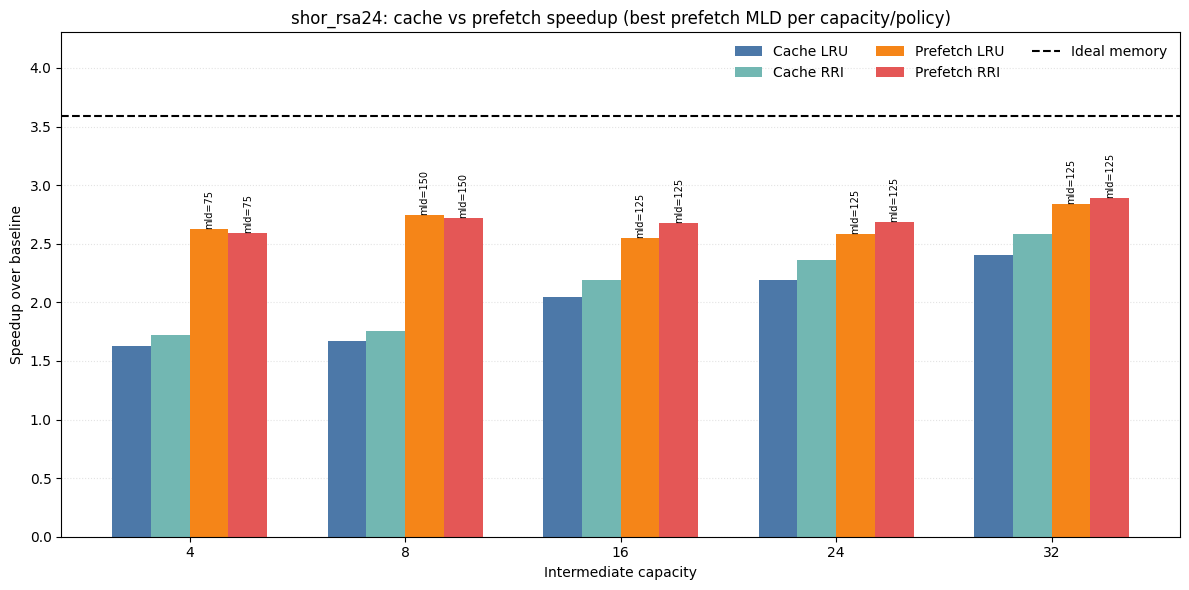

In [35]:
BENCHMARK = 'shor_rsa24'
plot_benchmark_speedup(BENCHMARK)
# Example for a fixed prefetch MLD instead of best-per-capacity:
# plot_benchmark_speedup(BENCHMARK, selected_mld=125)


(<Figure size 1560x1680 with 12 Axes>,
 [<Axes: title={'center': 'bose_hubbard_q'}, xlabel='Intermediate capacity', ylabel='Speedup over baseline'>,
  <Axes: title={'center': 'bose_hubbard_t'}, xlabel='Intermediate capacity'>,
  <Axes: title={'center': 'chromium_q'}, xlabel='Intermediate capacity'>,
  <Axes: title={'center': 'chromium_t'}, xlabel='Intermediate capacity', ylabel='Speedup over baseline'>,
  <Axes: title={'center': 'ethylene_oxide_q'}, xlabel='Intermediate capacity'>,
  <Axes: title={'center': 'ethylene_oxide_t'}, xlabel='Intermediate capacity'>,
  <Axes: title={'center': 'grover_3sat'}, xlabel='Intermediate capacity', ylabel='Speedup over baseline'>,
  <Axes: title={'center': 'hc3h2cn_q'}, xlabel='Intermediate capacity'>,
  <Axes: title={'center': 'hc3h2cn_t'}, xlabel='Intermediate capacity'>,
  <Axes: title={'center': 'manganese_nitride_q'}, xlabel='Intermediate capacity', ylabel='Speedup over baseline'>,
  <Axes: title={'center': 'manganese_nitride_t'}, xlabel='Interme

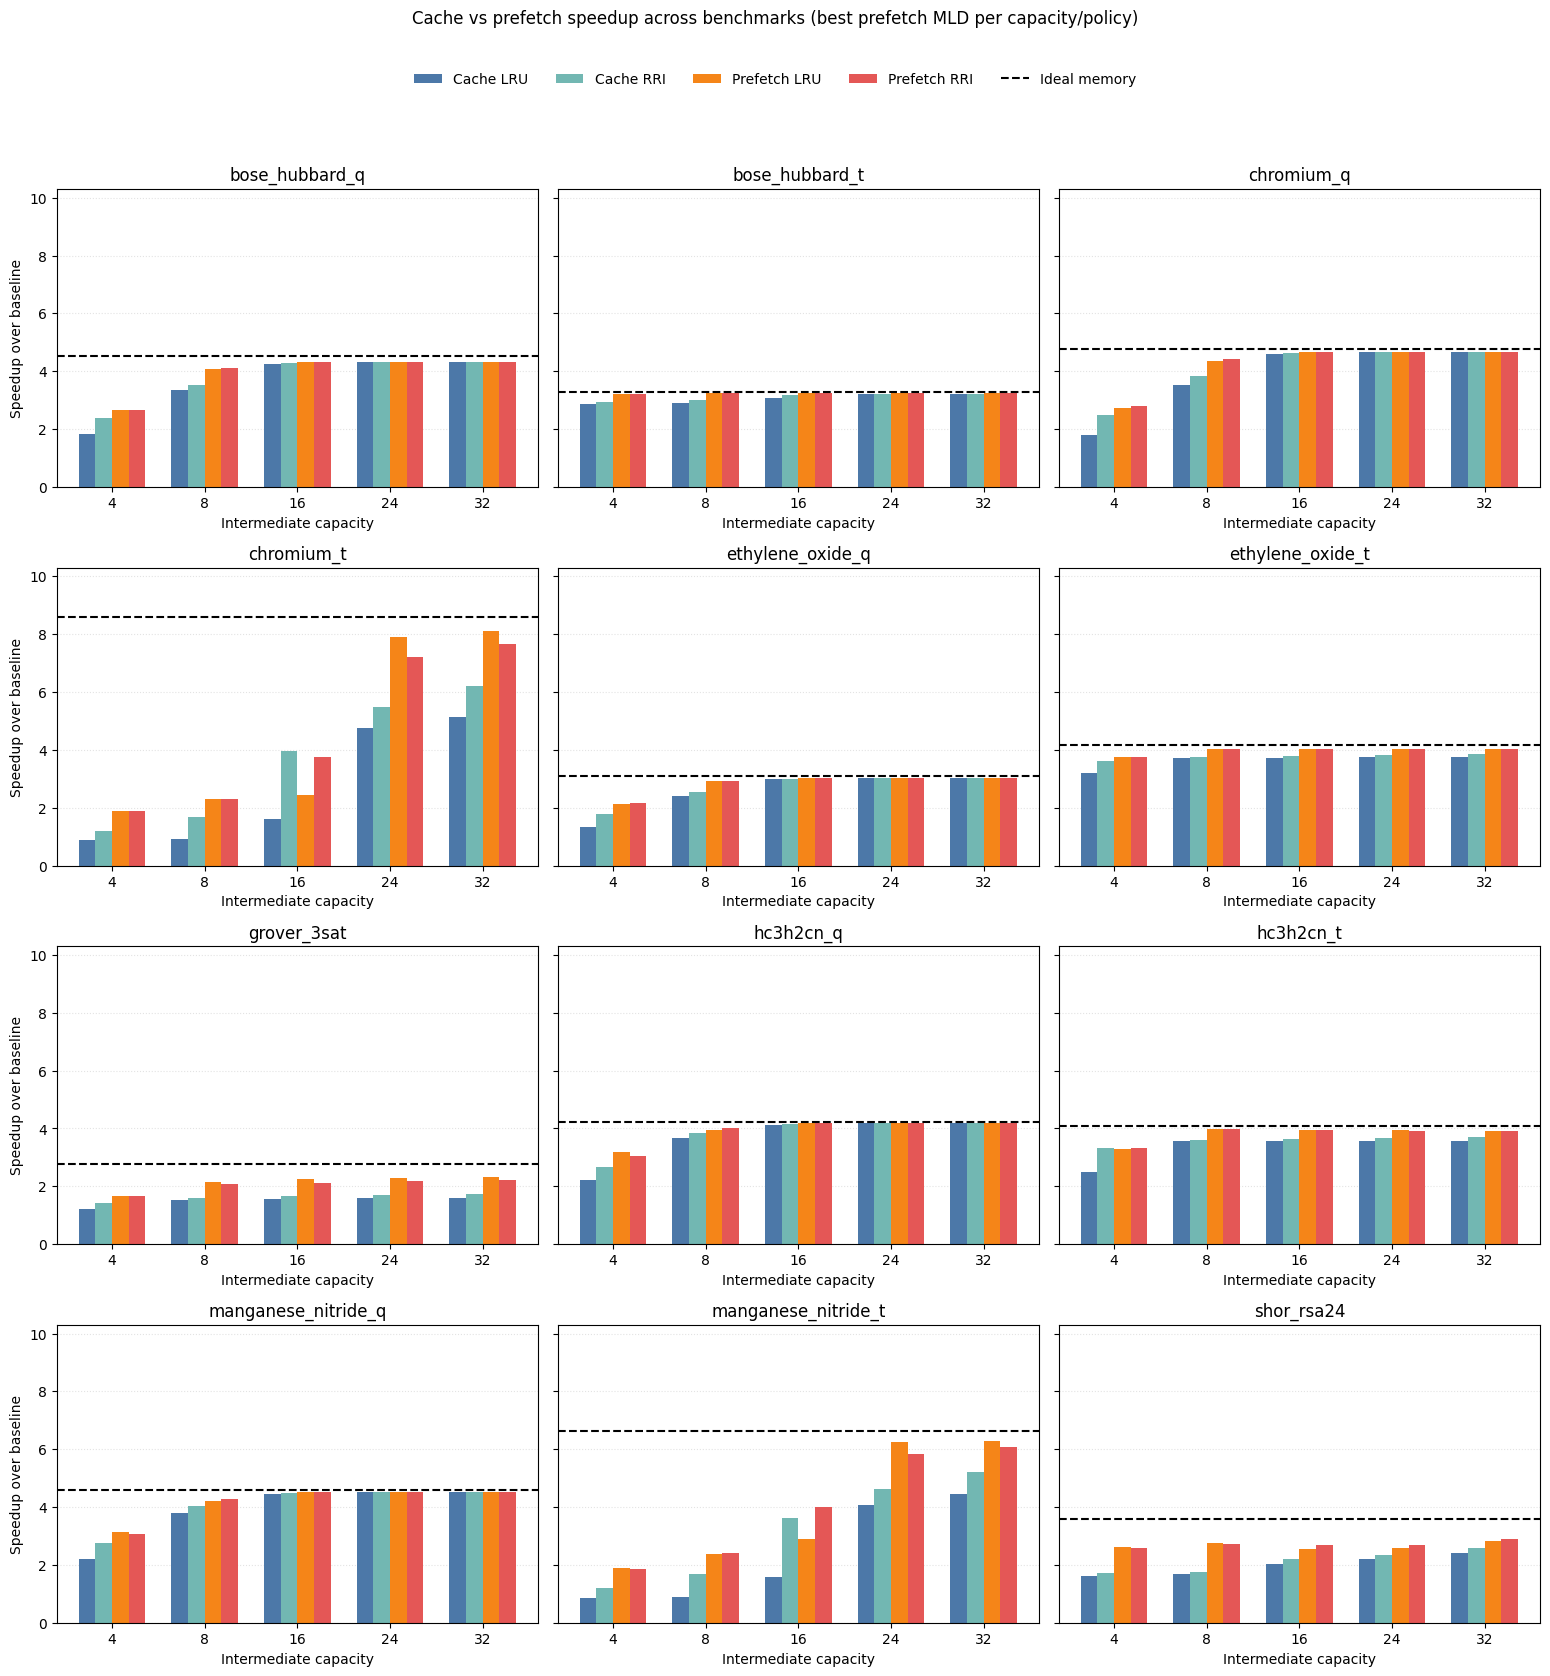

In [36]:
plot_all_benchmarks_speedup_grid()
# Example with a fixed prefetch MLD:
# plot_all_benchmarks_speedup_grid(selected_mld=125)


In [38]:
import math

def geometric_mean(values):
    values = [value for value in values if value is not None and value > 0]
    if not values:
        return None
    return math.exp(sum(math.log(value) for value in values) / len(values))


def speedup_gmean_by_approach_at_capacity(selected_capacity=8, labels=None, selected_mld=None, include_ideal_memory=True):
    if labels is None:
        labels = AVAILABLE_BENCHMARKS

    labels = list(labels)
    approach_values = {
        'cache_lru': [],
        'cache_rri': [],
        'prefetch_lru': [],
        'prefetch_rri': [],
    }
    if include_ideal_memory:
        approach_values['ideal_memory'] = []

    per_benchmark = {}
    for label in labels:
        plot_data = _benchmark_plot_data(label, selected_mld=selected_mld)

        benchmark_values = {
            'cache_lru': plot_data['cache_speedups'].get((selected_capacity, 'lru')),
            'cache_rri': plot_data['cache_speedups'].get((selected_capacity, 'rri')),
            'prefetch_lru': plot_data['prefetch_speedups'].get((selected_capacity, 'lru')),
            'prefetch_rri': plot_data['prefetch_speedups'].get((selected_capacity, 'rri')),
        }
        if include_ideal_memory:
            benchmark_values['ideal_memory'] = plot_data['ideal_speedup']

        per_benchmark[label] = benchmark_values

        for approach, value in benchmark_values.items():
            if value is not None:
                approach_values[approach].append(value)

    gmeans = {approach: geometric_mean(values) for approach, values in approach_values.items()}
    return {
        'selected_capacity': selected_capacity,
        'per_benchmark_speedups': per_benchmark,
        'gmean_of_speedups': gmeans,
    }


gmean_summary = speedup_gmean_by_approach_at_capacity(selected_capacity=8)
gmean_summary['gmean_of_speedups']


{'cache_lru': 2.3751702694440366,
 'cache_rri': 2.726468640768862,
 'prefetch_lru': 3.2610392772548344,
 'prefetch_rri': 3.271417839317539,
 'ideal_memory': 4.309275825672733}

(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'Optimal memory configuration sweep'}, xlabel='Logical qubits in memory', ylabel='Physical qubit count'>)

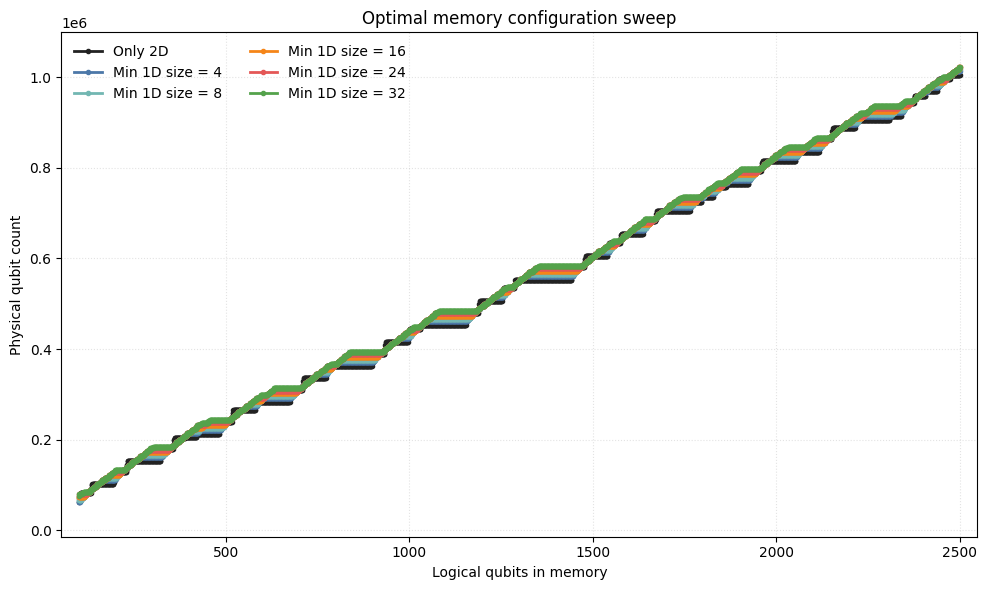

In [47]:
def _constraint_sort_key(label):
    if label == 'only_2d':
        return (-1, 0)
    return (0, int(label))

def plot_optimize_memory_config_sweep(csv_path=None, figsize=(10, 6)):
    if csv_path is None:
        candidates = [
            ROOT / 'build' / 'optimize_memory_config_sweep.csv',
            ROOT.parent / 'build' / 'optimize_memory_config_sweep.csv',
            ROOT / 'optimize_memory_config_sweep.csv',
            ROOT.parent / 'optimize_memory_config_sweep.csv',
            RESULTS_DIR / 'optimize_memory_config_sweep.csv',
            RESULTS_DIR.parent / 'build' / 'optimize_memory_config_sweep.csv',
        ]
        candidates = list(dict.fromkeys(candidates))
        csv_path = next((candidate for candidate in candidates if candidate.exists()), None)
        if csv_path is None:
            searched = '\n'.join(str(candidate) for candidate in candidates)
            raise FileNotFoundError(
                'Could not find optimize_memory_config_sweep.csv. Searched:\n' + searched
            )
    else:
        csv_path = Path(csv_path)

    rows = load_rows(csv_path)
    grouped = defaultdict(list)
    for row in rows:
        logical_qubits = to_int(row['logical_qubits'])
        physical_qubits = to_int(row['physical_qubits'])
        constraint = row['min_1d_size']
        if logical_qubits is None or physical_qubits is None:
            continue
        grouped[constraint].append((logical_qubits, physical_qubits))

    if not grouped:
        raise ValueError(f'No valid rows found in {csv_path}')

    fig, ax = plt.subplots(figsize=figsize)
    color_map = {
        'only_2d': '#222222',
        '4': '#4C78A8',
        '8': '#72B7B2',
        '16': '#F58518',
        '24': '#E45756',
        '32': '#54A24B',
    }

    for constraint in sorted(grouped.keys(), key=_constraint_sort_key):
        series = sorted(grouped[constraint], key=lambda pair: pair[0])
        x = [pair[0] for pair in series]
        y = [pair[1] for pair in series]
        label = 'Only 2D' if constraint == 'only_2d' else f'Min 1D size = {constraint}'
        ax.plot(x, y, marker='o', markersize=3, linewidth=2, label=label, color=color_map.get(constraint))

    ax.set_xlabel('Logical qubits in memory')
    ax.set_ylabel('Physical qubit count')
    ax.set_title('Optimal memory configuration sweep')
    ax.grid(True, linestyle=':', alpha=0.35)
    ax.set_axisbelow(True)
    ax.legend(frameon=False, ncols=2)
    ax.margins(x=0.02, y=0.08)
    plt.tight_layout()
    return fig, ax

plot_optimize_memory_config_sweep()


In [48]:
def average_min_1d_absolute_overhead_vs_only_2d(csv_path=None):
    if csv_path is None:
        candidates = [
            ROOT / 'build' / 'optimize_memory_config_sweep.csv',
            ROOT.parent / 'build' / 'optimize_memory_config_sweep.csv',
            ROOT / 'optimize_memory_config_sweep.csv',
            ROOT.parent / 'optimize_memory_config_sweep.csv',
            RESULTS_DIR / 'optimize_memory_config_sweep.csv',
            RESULTS_DIR.parent / 'build' / 'optimize_memory_config_sweep.csv',
        ]
        candidates = list(dict.fromkeys(candidates))
        csv_path = next((candidate for candidate in candidates if candidate.exists()), None)
        if csv_path is None:
            searched = '\n'.join(str(candidate) for candidate in candidates)
            raise FileNotFoundError('Could not find optimize_memory_config_sweep.csv. Searched:\n' + searched)
    else:
        csv_path = Path(csv_path)

    rows = load_rows(csv_path)
    by_constraint = defaultdict(dict)
    for row in rows:
        logical_qubits = to_int(row['logical_qubits'])
        physical_qubits = to_float(row['physical_qubits'])
        constraint = row['min_1d_size']
        if logical_qubits is None or physical_qubits is None:
            continue
        by_constraint[constraint][logical_qubits] = physical_qubits

    baseline = by_constraint.get('only_2d', {})
    if not baseline:
        raise ValueError('No only_2d rows found in sweep CSV')

    results = {}
    for constraint in sorted((key for key in by_constraint.keys() if key != 'only_2d'), key=lambda key: int(key)):
        overheads = []
        for logical_qubits, phys in by_constraint[constraint].items():
            base_phys = baseline.get(logical_qubits)
            if base_phys is None:
                continue
            overheads.append(phys - base_phys)
        results[f'min_1d_size={constraint}'] = (sum(overheads) / len(overheads)) if overheads else None

    return results

average_min_1d_absolute_overhead_vs_only_2d()


{'min_1d_size=4': 2699.262807163682,
 'min_1d_size=8': 4718.110787172011,
 'min_1d_size=16': 7710.374010828821,
 'min_1d_size=24': 10030.76218242399,
 'min_1d_size=32': 12187.696793002915}

(<Figure size 1600x600 with 1 Axes>,
 <Axes: title={'center': 'Cache vs prefetch relative speedups at intermediate capacity 8'}, xlabel='Benchmark', ylabel='Relative speedup over baseline'>)

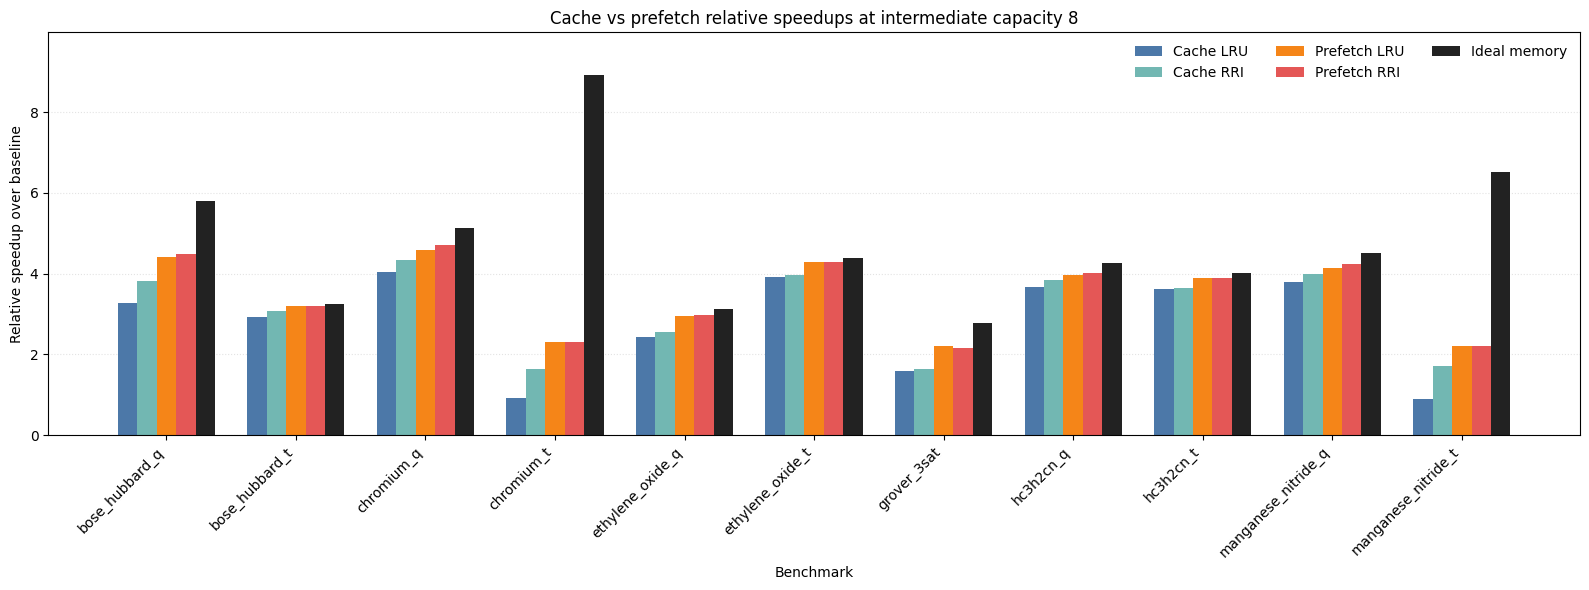

In [46]:
def plot_i8_cache_prefetch_relative_speedups(
    cache_csv=None,
    prefetch_csv=None,
    selected_mld=None,
    figsize=(16, 6),
):
    if cache_csv is None:
        cache_candidates = [
            RESULTS_DIR / 'cache_new_benchmarks_i8.csv',
            ROOT / 'results' / 'cache_new_benchmarks_i8.csv',
            ROOT / 'cache_new_benchmarks_i8.csv',
        ]
        cache_csv = next((candidate for candidate in cache_candidates if candidate.exists()), None)
        if cache_csv is None:
            raise FileNotFoundError('Could not find cache_new_benchmarks_i8.csv')
    else:
        cache_csv = Path(cache_csv)

    if prefetch_csv is None:
        prefetch_candidates = [
            RESULTS_DIR / 'prefetch_new_benchmarks_100M_i8.csv',
            ROOT / 'results' / 'prefetch_new_benchmarks_100M_i8.csv',
            ROOT / 'prefetch_new_benchmarks_100M_i8.csv',
        ]
        prefetch_csv = next((candidate for candidate in prefetch_candidates if candidate.exists()), None)
        if prefetch_csv is None:
            raise FileNotFoundError('Could not find prefetch_new_benchmarks_100M_i8.csv')
    else:
        prefetch_csv = Path(prefetch_csv)

    cache_rows = load_rows(cache_csv)
    prefetch_rows = load_rows(prefetch_csv)

    benchmarks = sorted(set(row['benchmark'] for row in cache_rows) | set(row['benchmark'] for row in prefetch_rows))
    approaches = ['cache_lru', 'cache_rri', 'prefetch_lru', 'prefetch_rri', 'ideal_memory']
    display_labels = {
        'cache_lru': 'Cache LRU',
        'cache_rri': 'Cache RRI',
        'prefetch_lru': 'Prefetch LRU',
        'prefetch_rri': 'Prefetch RRI',
        'ideal_memory': 'Ideal memory',
    }
    colors = {
        'cache_lru': '#4C78A8',
        'cache_rri': '#72B7B2',
        'prefetch_lru': '#F58518',
        'prefetch_rri': '#E45756',
        'ideal_memory': '#222222',
    }

    speedups = {approach: [] for approach in approaches}

    for benchmark in benchmarks:
        cache_benchmark_rows = [row for row in cache_rows if row['benchmark'] == benchmark]
        prefetch_benchmark_rows = [row for row in prefetch_rows if row['benchmark'] == benchmark]

        cache_baseline = next((row for row in cache_benchmark_rows if row['eviction_policy'] == 'eif_baseline'), None)
        prefetch_baseline = next((row for row in prefetch_benchmark_rows if row['eviction_policy'] == 'eif'), None)
        baseline_row = cache_baseline or prefetch_baseline
        baseline_ipc = to_float(baseline_row['ipc']) if baseline_row else None
        if baseline_ipc in (None, 0.0):
            raise ValueError(f'Could not determine baseline IPC for {benchmark}')

        cache_lru_row = next((row for row in cache_benchmark_rows if row['eviction_policy'] == 'lru'), None)
        cache_rri_row = next((row for row in cache_benchmark_rows if row['eviction_policy'] == 'rri'), None)

        prefetch_candidates = [
            row for row in prefetch_benchmark_rows
            if row['eviction_policy'] in {'lru', 'rri'} and to_int(row['intermediate_capacity']) == 8
        ]
        if selected_mld is not None:
            prefetch_candidates = [row for row in prefetch_candidates if to_int(row['min_layer_distance']) == selected_mld]

        prefetch_best = {}
        for policy in ['lru', 'rri']:
            rows_for_policy = [row for row in prefetch_candidates if row['eviction_policy'] == policy]
            prefetch_best[policy] = max(rows_for_policy, key=lambda row: to_float(row['ipc']) or float('-inf')) if rows_for_policy else None

        ideal_row = next((row for row in prefetch_benchmark_rows if row['eviction_policy'] == 'ideal_memory'), None)

        lookup = {
            'cache_lru': cache_lru_row,
            'cache_rri': cache_rri_row,
            'prefetch_lru': prefetch_best['lru'],
            'prefetch_rri': prefetch_best['rri'],
            'ideal_memory': ideal_row,
        }

        for approach in approaches:
            row = lookup[approach]
            ipc = to_float(row['ipc']) if row else None
            speedups[approach].append((ipc / baseline_ipc) if ipc is not None else None)

    fig, ax = plt.subplots(figsize=figsize)
    x = list(range(len(benchmarks)))
    width = 0.15
    offsets = {
        'cache_lru': -2 * width,
        'cache_rri': -1 * width,
        'prefetch_lru': 0,
        'prefetch_rri': 1 * width,
        'ideal_memory': 2 * width,
    }

    for approach in approaches:
        positions = [value + offsets[approach] for value in x]
        heights = [0 if value is None else value for value in speedups[approach]]
        ax.bar(positions, heights, width=width, label=display_labels[approach], color=colors[approach])

    ax.set_xticks(x)
    ax.set_xticklabels(benchmarks, rotation=45, ha='right')
    ax.set_xlabel('Benchmark')
    ax.set_ylabel('Relative speedup over baseline')
    title_suffix = 'best prefetch MLD per benchmark' if selected_mld is None else f'prefetch MLD={selected_mld}'
    ax.set_title(f'Cache vs prefetch relative speedups at intermediate capacity 8')
    ax.grid(axis='y', linestyle=':', alpha=0.35)
    ax.set_axisbelow(True)
    ax.legend(frameon=False, ncols=3)
    ax.margins(y=0.12)
    plt.tight_layout()
    return fig, ax

plot_i8_cache_prefetch_relative_speedups()
# Example with a fixed prefetch MLD:
# plot_i8_cache_prefetch_relative_speedups(selected_mld=100)


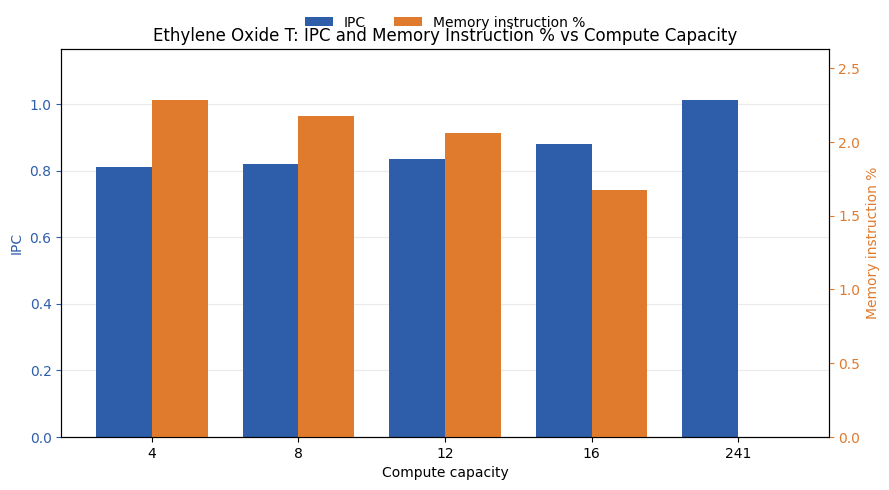

In [49]:
def plot_ethylene_oxide_t_capacity_sweep(csv_path=None, figsize=(9, 5)):
    if csv_path is None:
        candidates = [
            ROOT / 'build' / 'ethylene_oxide_t_capacity_sweep.csv',
            ROOT / 'ethylene_oxide_t_capacity_sweep.csv',
            RESULTS_DIR / 'ethylene_oxide_t_capacity_sweep.csv',
            RESULTS_DIR.parent / 'build' / 'ethylene_oxide_t_capacity_sweep.csv',
        ]
        csv_path = next((path for path in candidates if path.exists()), None)
        if csv_path is None:
            raise FileNotFoundError('Could not find ethylene_oxide_t_capacity_sweep.csv')

    rows = load_rows(csv_path)
    rows = sorted(rows, key=lambda row: to_int(row['compute_capacity']) or 0)

    capacities = [to_int(row['compute_capacity']) for row in rows]
    ipc_values = [to_float(row['ipc']) for row in rows]
    mem_pct_values = [to_float(row['memory_instruction_percentage']) for row in rows]

    x = list(range(len(capacities)))
    width = 0.38

    fig, ax_ipc = plt.subplots(figsize=figsize)
    ax_mem = ax_ipc.twinx()

    ipc_bars = ax_ipc.bar(
        [xi - width / 2 for xi in x],
        ipc_values,
        width=width,
        color='#2E5EAA',
        label='IPC',
    )
    mem_bars = ax_mem.bar(
        [xi + width / 2 for xi in x],
        mem_pct_values,
        width=width,
        color='#E07A2D',
        label='Memory instruction %',
    )

    ax_ipc.set_xticks(x)
    ax_ipc.set_xticklabels([str(cap) for cap in capacities])
    ax_ipc.set_xlabel('Compute capacity')
    ax_ipc.set_ylabel('IPC', color='#2E5EAA')
    ax_mem.set_ylabel('Memory instruction %', color='#E07A2D')
    ax_ipc.tick_params(axis='y', colors='#2E5EAA')
    ax_mem.tick_params(axis='y', colors='#E07A2D')
    ax_ipc.set_title('Ethylene Oxide T: IPC and Memory Instruction % vs Compute Capacity')
    ax_ipc.grid(axis='y', alpha=0.25)
    ax_ipc.set_axisbelow(True)
    ax_ipc.margins(y=0.15)
    ax_mem.margins(y=0.15)

    handles = [ipc_bars, mem_bars]
    labels = ['IPC', 'Memory instruction %']
    ax_ipc.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.12), ncol=2, frameon=False)

    plt.tight_layout()
    plt.show()


plot_ethylene_oxide_t_capacity_sweep()
